### scVI pipeline
#### Current pipeline
library size normalization -> log1p -> HVG -> scVI batch correction

In [18]:
# modules
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scipy as sp
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from pathlib import Path
import anndata as ad
import sys
import re
import os
import seaborn as sns
import scvi
import torch
### Import personal Utensils
sys.path.insert(0, "..")
import utils as ut

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [19]:
QCDir = Path("../../result/qc/qc.h5ad")
adata = sc.read_h5ad(QCDir)

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


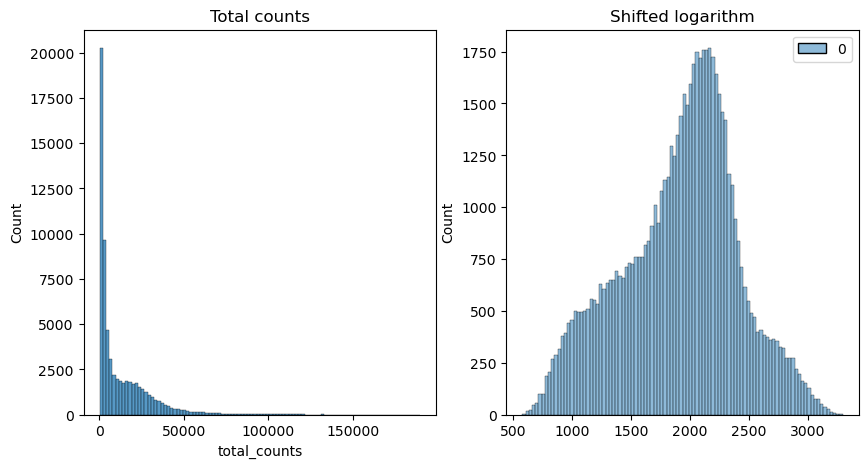

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [20]:
# library size normalization + log1p transform
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [21]:
# per-study HVG + intersection: avoids scRNA/snRNA bias
n_hvg_per_study = 4000

hvg_sets = {}
for study in adata.obs["Study"].unique():
    sub = adata[adata.obs["Study"] == study].copy()
    sc.pp.highly_variable_genes(
        sub,
        n_top_genes=n_hvg_per_study,
        flavor="seurat_v3",
        layer="counts",
        subset=False,
    )
    hvg_sets[study] = set(sub.var_names[sub.var["highly_variable"]])
    print(f"{study}: {len(hvg_sets[study])} HVGs")

shared = sorted(set.intersection(*hvg_sets.values()))
adata.var["highly_variable"] = adata.var_names.isin(shared)

print(f"Intersection: {len(shared)} genes")

crc06: 4000 HVGs
crc01: 4000 HVGs
Intersection: 1724 genes
SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [22]:
# subset to HVGs for scVI, using raw counts layer
adata_scvi = adata[:, adata.var["highly_variable"]].copy()
print(f"scVI input: {adata_scvi.shape}")

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    layer="counts",
    batch_key="Study",
)


model = scvi.model.SCVI(
    adata_scvi,
    n_latent=30,
    n_layers=2,
    dispersion="gene-batch",
    gene_likelihood="nb",
)
model.train(accelerator="gpu", max_epochs=400, early_stopping=True)

adata.obsm["X_scVI"] = model.get_latent_representation()

print(f"scVI latent shape: {adata.obsm['X_scVI'].shape}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


scVI input: (65335, 1724)


/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


scVI latent shape: (65335, 30)
SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: 
gene-batch, gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


/tmp/ipykernel_574757/853329070.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="leiden_scVI")


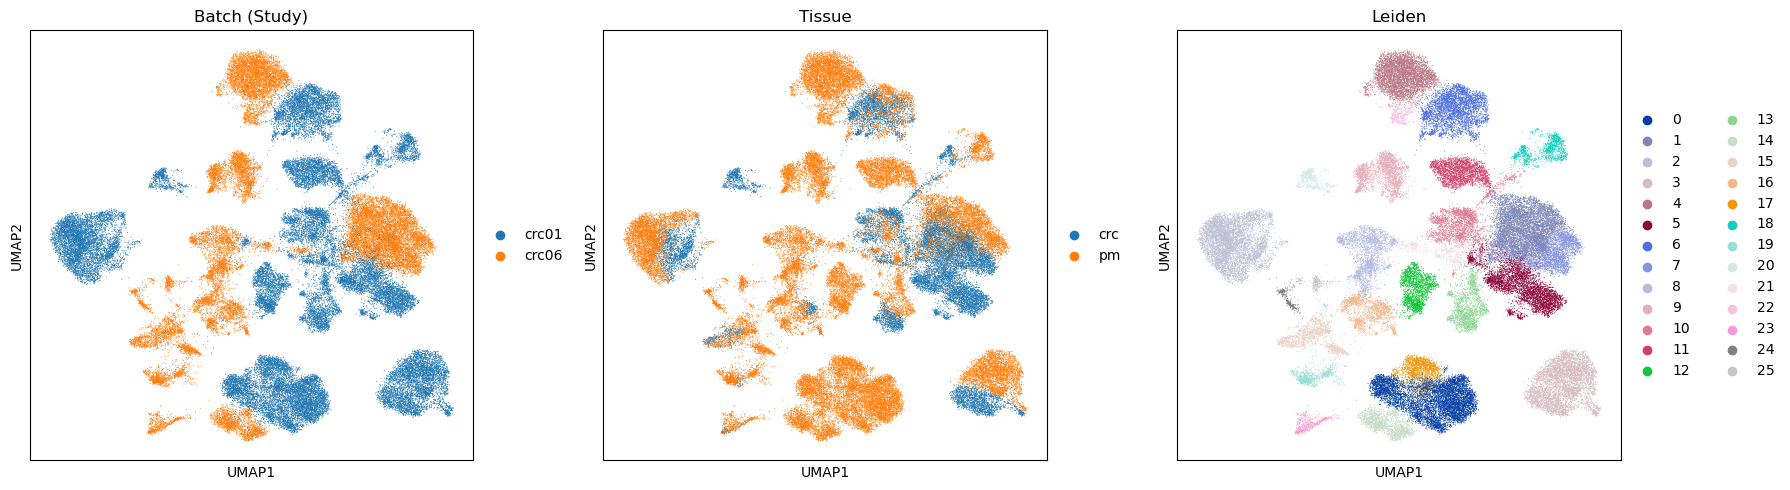

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: 
gene-batch, gene_likelihood: nb, latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False


In [23]:
# compute neighbors and UMAP on scVI latent space
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden_scVI")

# evaluate: batch mixing vs biology preservation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata, color="Study", ax=axes[0], show=False, title="Batch (Study)")
sc.pl.umap(adata, color="Tissue", ax=axes[1], show=False, title="Tissue")
sc.pl.umap(adata, color="leiden_scVI", ax=axes[2], show=False, title="Leiden")
plt.tight_layout()
plt.show()